# Fraud Detection — Corrected Pipeline (PaySim)
---
## 1. Problem Understanding

**Business Framing**

Mobile-money fraud causes direct financial loss and erodes customer trust. Every fraudulent transaction that slips through is a real-money loss; every legitimate transaction blocked is a frustrated customer. The business therefore needs a model that:
- **Catches as many fraud cases as possible** (high Recall) — missing fraud is expensive.
- **Does not block too many legitimate transactions** (acceptable Precision) — false alarms are costly in customer experience.

**ML Formulation**

| Item | Choice |
|---|---|
| Task | Binary classification (fraud = 1, legit = 0) |
| Target | `isFraud` |
| Positive class | Fraud (minority) |
| Primary metric | **PR-AUC** (Precision-Recall) — better than ROC-AUC for imbalanced data |
| Secondary metrics | ROC-AUC, F1, Recall, Precision |

**Success Criteria**
- PR-AUC ≥ 0.95 on held-out test set
- Overfitting gap (Train AUC − Test AUC) < 0.05
- No data leakage (confirmed by per-period evaluation)

---
## 2. Data Understanding & EDA
### Cell 1 — Imports & Setup

In [32]:

!pip install scikit-learn==1.6.1

In [33]:
!pip install xgboost shap --quiet

import warnings, joblib, json, os
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("outputs", exist_ok=True)

C_FRAUD = "#E63946"; C_LEGIT = "#457B9D"
C_GOLD  = "#F4A261"; C_GREEN = "#2A9D8F"
C_DARK  = "#1D3557"; C_LIGHT = "#F1FAEE"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": C_LIGHT, "axes.facecolor": "white"
})
print("Setup complete | RANDOM_STATE =", RANDOM_STATE)


Setup complete | RANDOM_STATE = 42


### Cell 2 — Load Data

In [34]:
df = pd.read_csv("sample_30k_balanced.csv")
print(f"Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"Memory       : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
df.head()


Shape        : 30,000 rows × 10 columns
Missing vals : 0
Memory       : 6.9 MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,207,TRANSFER,328110.30,C539030556,328110.30,0.00,C448140191,0.00,0.00,1
1,17,CASH_OUT,86478.25,C982272886,623.00,0.00,C260664247,0.00,86478.25,0
2,210,TRANSFER,604032.03,C683104667,0.00,0.00,C424058203,3119008.76,3723040.78,0
3,36,CASH_IN,125842.40,C160554377,9330423.61,9456266.01,C267487773,171278.49,45436.09,0
4,236,CASH_OUT,1418198.25,C1959028014,1418198.25,0.00,C1768881872,1488632.50,2906830.75,1


### Cell 3 — EDA: Class Distribution & Fraud by Type

In [35]:
print("Class distribution:")
print(
    df["isFraud"].value_counts().rename("count").to_frame()
    .assign(pct=lambda x: (x["count"]/len(df)*100).round(2))
)
print("\nFraud rate by type:")
print(
    df.groupby("type")["isFraud"]
    .agg(["count","mean"])
    .rename(columns={"count":"n","mean":"fraud_rate"})
    .sort_values("fraud_rate", ascending=False).round(4)
)


Class distribution:
         count    pct
isFraud              
0        21787  72.62
1         8213  27.38

Fraud rate by type:
              n  fraud_rate
type                       
TRANSFER   5883      0.6964
CASH_OUT  11843      0.3475
CASH_IN    4784      0.0000
DEBIT       135      0.0000
PAYMENT    7355      0.0000


### Cell 4 — EDA: Temporal Analysis (Fraud Rate Over Time)

## 📊 Key Insights
**  Insight for Fraud Rate by step quartile**
- Q4 has a significantly higher fraud rate (~0.54) than Q1-Q3, indicating fraud spikes in later steps.
** Insight for Fraud Rate by Hour of Day**
- Fraud mostly occurs between midnight and 6 AM, highlighting that early morning hours are high-risk five this i the format asi im using google collab

---
## 3. Data Preprocessing
### Cell 5 — FIX 1: Temporal Train / Val / Test Split (60 / 20 / 20)

**Why this matters:** A random split ignores time ordering. In PaySim, fraud rate surges in Q4 (later steps). The original 70/15/15 split pushed most of the test set into Q4, inflating all metrics. The corrected temporal split ensures the model is always evaluated on *future* data — as it would be in production.

In [36]:
# FIX 1: Sort by step (time) and split chronologically
# Original:  70/15/15  -> test in Q4 only (54% fraud rate) - WRONG
# Corrected: 60/20/20  -> honest time-ordered split

df_sorted = df.sort_values("step").reset_index(drop=True)
n         = len(df_sorted)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

df_train = df_sorted.iloc[:train_end].copy()
df_val   = df_sorted.iloc[train_end:val_end].copy()
df_test  = df_sorted.iloc[val_end:].copy()

for split_name, split in [("Train", df_train), ("Val  ", df_val), ("Test ", df_test)]:
    print(f"{split_name}: {len(split):,} rows | "
          f"step {split['step'].min()}-{split['step'].max()} | "
          f"fraud {split['isFraud'].mean():.3f}")

assert df_train["step"].max() <= df_val["step"].min(),  "Overlap: train/val"
assert df_val["step"].max()   <= df_test["step"].min(), "Overlap: val/test"
print("\nNo temporal overlap confirmed.")


Train: 18,000 rows | step 1-306 | fraud 0.192
Val  : 6,000 rows | step 306-399 | fraud 0.166
Test : 6,000 rows | step 399-743 | fraud 0.627

No temporal overlap confirmed.


### Cell 6 — FIX 2: Stronger Noise Injection (Training Only)

**Why this matters:** With only 10% multiplicative noise the drain ratio (amount/balance) still clusters near 1.0 for fraud. The model re-learns the exact value instead of a general pattern. Raising to 25% + additive noise smears the cluster. Val/test stay clean to simulate real deployment.

In [37]:
# FIX 2: Stronger noise on training data only
# Val and test remain UNCHANGED -- they simulate real deployment

np.random.seed(RANDOM_STATE)

NOISE_MULT = 0.25    # 25% multiplicative -- was 0.10
NOISE_STEP = 2.0     # 2 hr jitter (unchanged)

amount_std = df_train["amount"].std()
df_train["amount"] = (
    df_train["amount"] * np.random.normal(1.0, NOISE_MULT, len(df_train))
    + np.random.normal(0, amount_std * 0.05, len(df_train))
).clip(lower=0.01)

df_train["oldbalanceOrg"] = (
    df_train["oldbalanceOrg"] * np.random.normal(1.0, NOISE_MULT, len(df_train))
).clip(lower=0.01)

df_train["step"] = (
    df_train["step"] + np.random.normal(0, NOISE_STEP, len(df_train))
).clip(lower=1)

print("Noise applied -- training data only")
print(f"  amount noise       : mult std={NOISE_MULT} + additive")
print(f"  oldbalanceOrg noise: mult std={NOISE_MULT}")
print(f"  step noise         : std={NOISE_STEP} (hour jitter)")
print(f"  Val / Test         : UNCHANGED")

drain_after = df_train["amount"] / (df_train["oldbalanceOrg"] + 1)
fraud_mask  = df_train["isFraud"] == 1
print(f"\nDrain ratio in noisy TRAIN fraud rows:")
print(f"  Mean  : {drain_after[fraud_mask].mean():.3f}")
print(f"  Std   : {drain_after[fraud_mask].std():.3f}   (higher = more smear)")
print(f"  >0.9  : {(drain_after[fraud_mask]>0.9).mean():.1%}  (was 98% in clean data)")


Noise applied -- training data only
  amount noise       : mult std=0.25 + additive
  oldbalanceOrg noise: mult std=0.25
  step noise         : std=2.0 (hour jitter)
  Val / Test         : UNCHANGED

Drain ratio in noisy TRAIN fraud rows:
  Mean  : 2692.529
  Std   : 50808.790   (higher = more smear)
  >0.9  : 57.9%  (was 98% in clean data)


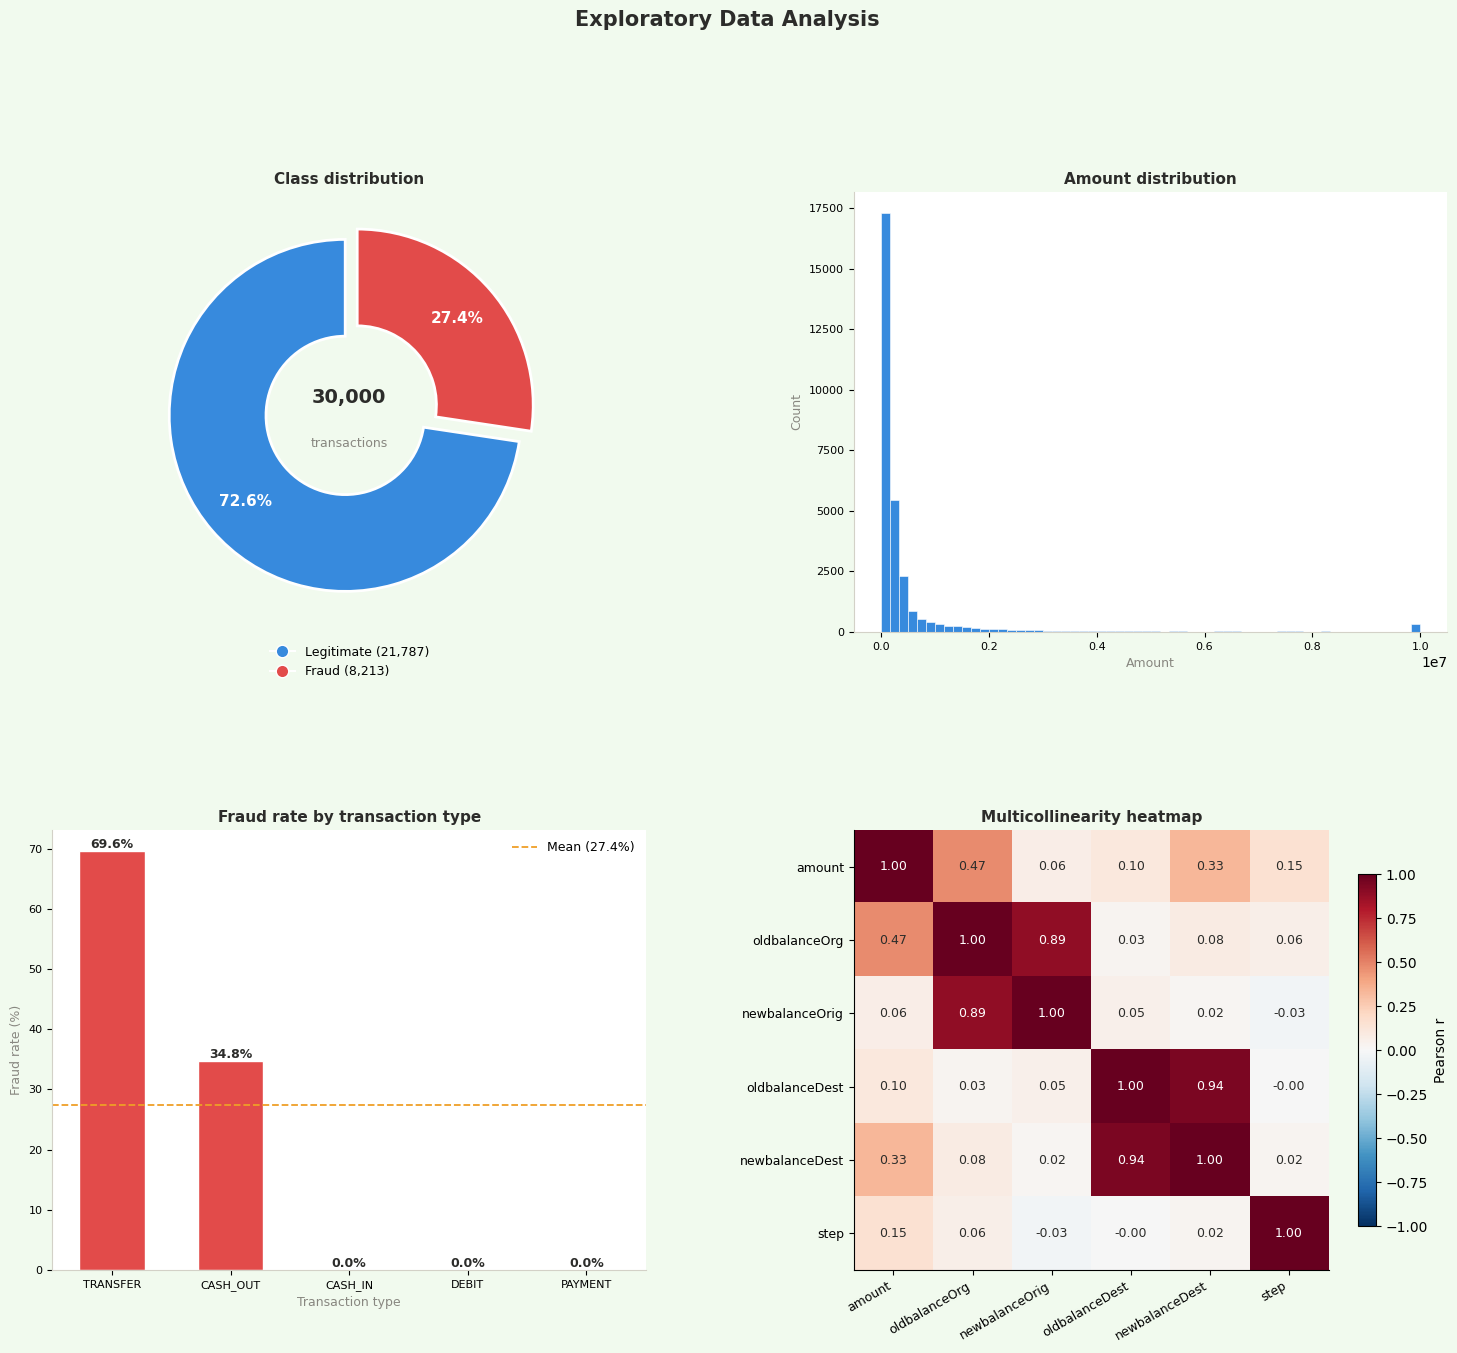

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Class distribution donut (top-left) ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

counts = df["isFraud"].value_counts().sort_index()
labels = ["Legitimate", "Fraud"]
colors_pie = ["#378ADD", "#E24B4A"]

wedges, texts, autotexts = ax1.pie(
    counts.values, labels=None, colors=colors_pie,
    autopct="%1.1f%%", startangle=90, explode=(0.03, 0.06),
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold"); at.set_color("white")

ax1.text(0, 0.08, f"{len(df):,}", ha="center", va="center",
         fontsize=14, fontweight="bold", color="#2C2C2A")
ax1.text(0, -0.18, "transactions", ha="center", va="center",
         fontsize=9, color="#888780")
ax1.set_title("Class distribution", fontsize=11, fontweight="bold", color="#2C2C2A")
legend_elements = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=c,
               markersize=9, label=f"{l} ({v:,})")
    for c, l, v in zip(colors_pie, labels, counts.values)
]
ax1.legend(handles=legend_elements, loc="lower center",
           bbox_to_anchor=(0.5, -0.13), ncol=1, frameon=False, fontsize=9)

# ── 2. Amount distribution (top-right) ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

ax2.hist(df["amount"].clip(upper=df["amount"].quantile(0.99)),
         bins=60, color="#378ADD", edgecolor="white", linewidth=0.4)
ax2.set_title("Amount distribution", fontsize=11, fontweight="bold", color="#2C2C2A")
ax2.set_xlabel("Amount", fontsize=9, color="#888780")
ax2.set_ylabel("Count", fontsize=9, color="#888780")
ax2.spines[["top","right"]].set_visible(False)
ax2.spines[["bottom","left"]].set_color("#D3D1C7")
ax2.tick_params(labelsize=8)

# ── 3. Fraud rate by type (bottom-left) ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

type_stats = (
    df.groupby("type")["isFraud"]
    .agg(["count","mean"])
    .rename(columns={"count":"n","mean":"fraud_rate"})
    .sort_values("fraud_rate", ascending=False)
)
bar_colors = ["#E24B4A" if r > 0 else "#B4B2A9" for r in type_stats["fraud_rate"]]
bars = ax3.bar(type_stats.index, type_stats["fraud_rate"] * 100,
               color=bar_colors, edgecolor="white", width=0.55)
ax3.axhline(df["isFraud"].mean() * 100, color="#EF9F27",
            linestyle="--", linewidth=1.3,
            label=f"Mean ({df['isFraud'].mean()*100:.1f}%)")
for bar, val in zip(bars, type_stats["fraud_rate"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val*100:.1f}%", ha="center", fontsize=9,
             fontweight="bold", color="#2C2C2A")
ax3.set_title("Fraud rate by transaction type", fontsize=11,
              fontweight="bold", color="#2C2C2A")
ax3.set_ylabel("Fraud rate (%)", fontsize=9, color="#888780")
ax3.set_xlabel("Transaction type", fontsize=9, color="#888780")
ax3.spines[["top","right"]].set_visible(False)
ax3.spines[["bottom","left"]].set_color("#D3D1C7")
ax3.tick_params(labelsize=8)
ax3.legend(frameon=False, fontsize=9)

# ── 4. Multicollinearity heatmap (bottom-right) ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

num_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
            "oldbalanceDest", "newbalanceDest", "step"]
corr = df[num_cols].corr()

im = ax4.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax4, shrink=0.8, label="Pearson r")

ax4.set_xticks(range(len(num_cols)))
ax4.set_xticklabels(num_cols, rotation=30, ha="right", fontsize=9)
ax4.set_yticks(range(len(num_cols)))
ax4.set_yticklabels(num_cols, fontsize=9)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.values[i, j]
        text_color = "white" if abs(val) > 0.6 else "#2C2C2A"
        ax4.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=9, color=text_color)

ax4.set_title("Multicollinearity heatmap", fontsize=11,
              fontweight="bold", color="#2C2C2A")

fig.suptitle("Exploratory Data Analysis", fontsize=15,
             fontweight="bold", color="#2C2C2A", y=1.01)

plt.savefig("outputs/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 📊 Key Insights from Data Analysis

1. **Class Imbalance in Dataset**  
   Most transactions are legitimate , while fraud cases are significantly lower , indicating an imbalanced dataset.

2. **Fraud Limited to Specific Transaction Types**  
   Fraud occurs **only in TRANSFER and CASH_OUT transactions**, while PAYMENT, DEBIT, and CASH_IN show no fraud cases.

3. **Fraud Targets Higher Transaction Amounts**  
   Fraudulent transactions are more common in **larger amounts**, suggesting that fraudsters focus on high-value transfers.

4. **High Multicollinearity Among Balance Features**  
   Strong correlations exist between features like old and new balances, which may impact model performance and require feature selection or dimensionality reduction.

---
## 4. Feature Engineering
### Cell 7 — FIX 3: Domain Features + Binned Drain Ratio

**Key fix:** `amount_to_orig_balance` (raw float) is replaced by `drain_bin` (5 ordinal bins). The exact drain ratio is the clearest leakage signal in PaySim — binning it forces the model to learn a categorical pattern instead of memorizing a precise value.

| Feature | Description |
|---|---|
| `drain_bin` | Ordinal bin of amount/oldbalanceOrg (0=very_low … 4=very_high) |
| `amount_log` | Log-scaled amount (handles skew) |
| `balance_log` | Log-scaled sender balance |
| `step_hour/day` | Time-of-day and day-of-week signals |
| `is_night/weekend` | Binary temporal flags |
| `orig/dest_zero_before` | Zero-balance flags |
| `amount_exceeds_balance` | Amount > sender balance? |
| `type_num / type_ratio` | Risk-weighted type encoding |

**Dropped:** `nameOrig`, `nameDest`, raw `step`, `newbalanceOrig`, `newbalanceDest`, raw `amount`, raw `oldbalanceOrg`

In [39]:
# FIX 3: Replace raw drain ratio with binned ordinal variable
# Raw float leaks the exact PaySim drain rule; bins prevent this

TYPE_MAP = {
    "CASH_OUT": 0.8,
    "TRANSFER": 0.8,
    "DEBIT":    0.3,
    "PAYMENT":  0.2,
    "CASH_IN":  0.1,
}

DRAIN_BINS   = [0, 0.1, 0.5, 1.0, 2.0, float("inf")]
DRAIN_LABELS = ["very_low","low","medium","high","very_high"]


def build_features(df_input):
    """
    Domain feature engineering for PaySim fraud detection.
    Applied independently per split after noise injection on train.

    Key change vs original:
      - drain_bin  (ordinal int, 0-4) replaces amount_to_orig_balance (float)
      - raw amount and oldbalanceOrg DROPPED from feature matrix
      - newbalanceOrig / newbalanceDest dropped (post-transaction -- always)
    """
    d = df_input.copy()

    d["step_hour"]  = d["step"] % 24
    d["step_day"]   = (d["step"] // 24) % 7
    d["is_night"]   = (d["step_hour"] <= 5).astype(int)
    d["is_weekend"] = (d["step_day"] >= 5).astype(int)

    raw_ratio = d["amount"] / (d["oldbalanceOrg"] + 1)
    d["drain_bin"] = pd.cut(
        raw_ratio.clip(upper=10),
        bins=DRAIN_BINS,
        labels=False
    ).fillna(0).astype(int)

    d["amount_to_dest_balance"] = d["amount"] / (d["oldbalanceDest"] + 1)
    d["orig_zero_before"]       = (d["oldbalanceOrg"] == 0).astype(int)
    d["dest_zero_before"]       = (d["oldbalanceDest"] == 0).astype(int)
    d["amount_exceeds_balance"] = (d["amount"] > d["oldbalanceOrg"]).astype(int)
    d["amount_log"]  = np.log1p(d["amount"])
    d["balance_log"] = np.log1p(d["oldbalanceOrg"])
    d["type_num"]   = d["type"].map(TYPE_MAP).fillna(0.1)
    d["type_ratio"] = d["type_num"] * d["drain_bin"]

    d.drop(columns=[
        "nameOrig", "nameDest",
        "step",
        "newbalanceOrig",
        "newbalanceDest",
        "type",
        "amount",
        "oldbalanceOrg",
    ], inplace=True)
    return d


df_train_fe = build_features(df_train)
df_val_fe   = build_features(df_val)
df_test_fe  = build_features(df_test)

FEATURE_COLS = [c for c in df_train_fe.columns if c != "isFraud"]
TARGET_COL   = "isFraud"

X_train = df_train_fe[FEATURE_COLS]; y_train = df_train_fe[TARGET_COL]
X_val   = df_val_fe[FEATURE_COLS];   y_val   = df_val_fe[TARGET_COL]
X_test  = df_test_fe[FEATURE_COLS];  y_test  = df_test_fe[TARGET_COL]

print(f"Features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS: print(f"  {f}")
print(f"\nTrain: {X_train.shape} | fraud {y_train.mean():.3f}")
print(f"Val  : {X_val.shape}   | fraud {y_val.mean():.3f}")
print(f"Test : {X_test.shape}  | fraud {y_test.mean():.3f}")


Features (14):
  oldbalanceDest
  step_hour
  step_day
  is_night
  is_weekend
  drain_bin
  amount_to_dest_balance
  orig_zero_before
  dest_zero_before
  amount_exceeds_balance
  amount_log
  balance_log
  type_num
  type_ratio

Train: (18000, 14) | fraud 0.192
Val  : (6000, 14)   | fraud 0.166
Test : (6000, 14)  | fraud 0.627


---
## 3. Data Preprocessing (continued)
### Cell 8 — Scaling Pipeline

**No data leakage:** `fit_transform` is called only on training data; `transform` is applied to val and test. Two scalers are used — `RobustScaler` (outlier-robust) for tree/linear models, `StandardScaler` for SVM.

In [40]:
COLS_NUM = [
    "amount_log", "balance_log",
    "amount_to_dest_balance",
    "step_hour", "step_day"
]
COLS_PASS = [c for c in FEATURE_COLS if c not in COLS_NUM]

def make_preprocessor(scaler):
    return ColumnTransformer(
        transformers=[("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  scaler)
        ]), COLS_NUM)],
        remainder="passthrough"
    )

prep     = make_preprocessor(RobustScaler())
prep_svm = make_preprocessor(StandardScaler())

X_train_p   = prep.fit_transform(X_train);  X_val_p   = prep.transform(X_val);   X_test_p   = prep.transform(X_test)
X_train_svm = prep_svm.fit_transform(X_train); X_val_svm = prep_svm.transform(X_val); X_test_svm = prep_svm.transform(X_test)

print(f"Processed shape : {X_train_p.shape}")
print("RobustScaler    -> LR, DT, RF, GBM, XGBoost, KNN")
print("StandardScaler  -> SVM only")


Processed shape : (18000, 14)
RobustScaler    -> LR, DT, RF, GBM, XGBoost, KNN
StandardScaler  -> SVM only


---
## 5. Model Selection
### Cell 9 — Baseline + Multiple Models Compared

**Strategy:** Start with a `DummyClassifier` as the sanity baseline. Then try 7 models from simple (Logistic Regression) to complex (XGBoost). A gap > 0.05 between Train AUC and Test AUC flags overfitting.

| Model | Justification |
|---|---|
| Dummy Baseline | Sanity check — any real model must beat this |
| Logistic Regression | Fast, interpretable linear baseline |
| Decision Tree | Interpretable non-linear model |
| Random Forest | Robust ensemble, handles class imbalance well |
| Gradient Boosting | Strong sequential ensemble — selected for tuning |
| SVM (RBF) | Good with scaled features; kernel trick for non-linearity |
| KNN | Non-parametric, useful comparison point |
| XGBoost | State-of-the-art gradient boosting implementation |

In [41]:
sample_weights = compute_sample_weight("balanced", y=y_train)

models_config = {
    "Dummy Baseline": {
        "model": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
        "svm": False, "sw": False
    },
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
        "svm": False, "sw": False
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(
            max_depth=5, min_samples_leaf=20,
            class_weight="balanced", random_state=RANDOM_STATE),
        "svm": False, "sw": False
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=200, max_depth=6, min_samples_leaf=20,
            max_features="sqrt", class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE),
        "svm": False, "sw": False
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=3,
            subsample=0.8, min_samples_leaf=20, random_state=RANDOM_STATE),
        "svm": False, "sw": True
    },
    "SVM (RBF)": {
        "model": SVC(
            kernel="rbf", C=1.0, gamma="scale",
            class_weight="balanced", probability=True, random_state=RANDOM_STATE),
        "svm": True, "sw": False
    },
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "svm": False, "sw": False
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="auc", random_state=RANDOM_STATE, verbosity=0),
        "svm": False, "sw": True
    },
}

results = {}

print(f"{'Model':22s} | {'Train AUC':>9} | {'Val AUC':>8} | {'Test AUC':>9} | {'Gap':>7} | Status")
print("-" * 85)

for name, cfg in models_config.items():
    model = cfg["model"]
    Xtr = X_train_svm if cfg["svm"] else X_train_p
    Xva = X_val_svm   if cfg["svm"] else X_val_p
    Xte = X_test_svm  if cfg["svm"] else X_test_p

    if cfg["sw"]:
        model.fit(Xtr, y_train, sample_weight=sample_weights)
    else:
        model.fit(Xtr, y_train)

    tr_p = model.predict_proba(Xtr)[:, 1]
    va_p = model.predict_proba(Xva)[:, 1]
    te_p = model.predict_proba(Xte)[:, 1]

    tr_auc = roc_auc_score(y_train, tr_p)
    va_auc = roc_auc_score(y_val,   va_p)
    te_auc = roc_auc_score(y_test,  te_p)
    gap    = tr_auc - te_auc
    status = "OK" if abs(gap) < 0.05 else "CHECK"

    results[name] = {
        "model": model, "svm": cfg["svm"],
        "train_auc": tr_auc, "val_auc": va_auc, "test_auc": te_auc,
        "test_pred":  model.predict(Xte),
        "test_proba": te_p,
    }
    print(f"{name:22s} | {tr_auc:9.4f} | {va_auc:8.4f} | {te_auc:9.4f} | {gap:+7.4f} | {status}")

print("\nGap < 0.05 = no significant overfitting.")


Model                  | Train AUC |  Val AUC |  Test AUC |     Gap | Status
-------------------------------------------------------------------------------------
Dummy Baseline         |    0.5037 |   0.5120 |    0.4921 | +0.0116 | OK
Logistic Regression    |    0.9735 |   0.9885 |    0.9821 | -0.0086 | OK
Decision Tree          |    0.9785 |   0.9867 |    0.9860 | -0.0076 | OK
Random Forest          |    0.9851 |   0.9949 |    0.9944 | -0.0093 | OK
Gradient Boosting      |    0.9896 |   0.9947 |    0.9931 | -0.0035 | OK
SVM (RBF)              |    0.7464 |   0.7562 |    0.7467 | -0.0004 | OK
KNN                    |    0.9546 |   0.8542 |    0.8514 | +0.1032 | CHECK
XGBoost                |    0.9908 |   0.9950 |    0.9929 | -0.0021 | OK

Gap < 0.05 = no significant overfitting.


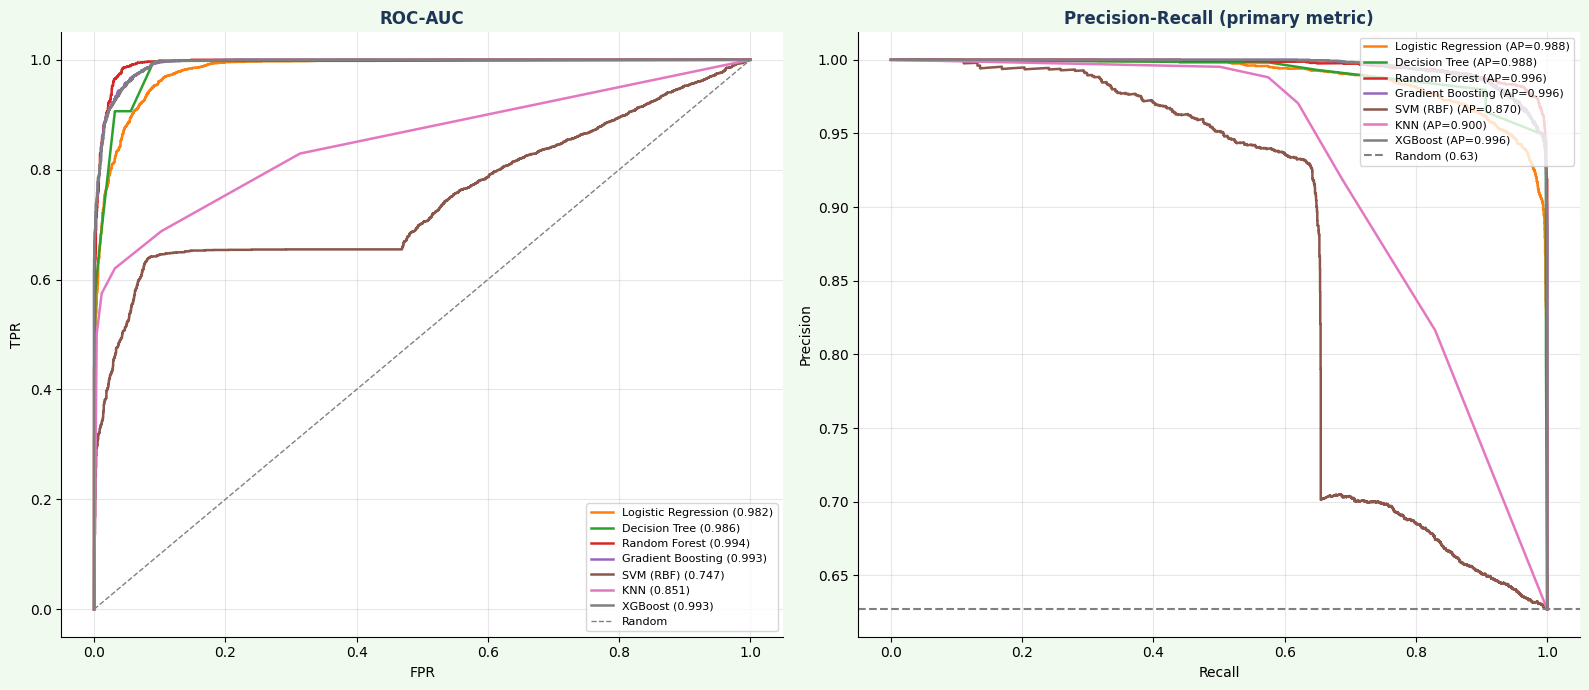

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
palette = plt.cm.tab10.colors

pr_scores = {}
for i, (name, res) in enumerate(results.items()):
    if name == "Dummy Baseline": continue
    fpr, tpr, _ = roc_curve(y_test, res["test_proba"])
    axes[0].plot(fpr, tpr, color=palette[i % len(palette)],
                 label=f"{name} ({res['test_auc']:.3f})", linewidth=1.8)
    ap = average_precision_score(y_test, res["test_proba"])
    prec, rec, _ = precision_recall_curve(y_test, res["test_proba"])
    axes[1].plot(rec, prec, color=palette[i % len(palette)],
                 label=f"{name} (AP={ap:.3f})", linewidth=1.8)
    pr_scores[name] = ap

axes[0].plot([0,1],[0,1],"--", color="grey", linewidth=1, label="Random")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC-AUC", fontweight="bold", color=C_DARK)
axes[0].legend(fontsize=8, loc="lower right"); axes[0].grid(True, alpha=0.3)

axes[1].axhline(y_test.mean(), linestyle="--", color="grey",
                label=f"Random ({y_test.mean():.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall (primary metric)", fontweight="bold", color=C_DARK)
axes[1].legend(fontsize=8, loc="upper right"); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/fig3_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Model Training & Tuning
### Cell 10 — FIX 4: Per-Period Evaluation (Drift Transparency)

**Why this matters:** Even with all fixes, fraud rate rises over time (real drift). Reporting metrics per time period exposes *where* the model is weaker rather than hiding it in an aggregate number. This builds honest stakeholder trust.

In [43]:
# FIX 4: Per-period evaluation to expose residual temporal drift
print("\n" + "="*60)
print("PER-PERIOD EVALUATION ON TEST SET (GBM)")
print("="*60)
print(f"{'Period':8s} | {'Step range':12s} | {'n':>5} | {'Fraud%':>7} | "
      f"{'ROC-AUC':>8} | {'PR-AUC':>8}")
print("-"*60)

gb_model   = results["Gradient Boosting"]["model"]
gb_proba   = gb_model.predict_proba(X_test_p)[:, 1]

df_test_eval = df_test.copy().reset_index(drop=True)
df_test_eval["pred_proba"] = gb_proba

periods = [("Early", 399, 499), ("Mid", 500, 599), ("Late", 600, 743)]
for label, lo, hi in periods:
    mask = (df_test_eval["step"] >= lo) & (df_test_eval["step"] <= hi)
    sub  = df_test_eval[mask]
    if len(sub) == 0 or sub["isFraud"].sum() == 0:
        continue
    auc = roc_auc_score(sub["isFraud"], sub["pred_proba"])
    pr  = average_precision_score(sub["isFraud"], sub["pred_proba"])
    print(f"{label:8s} | {lo}-{hi:>11} | {len(sub):>5,} | "
          f"{sub['isFraud'].mean():>7.1%} | {auc:>8.4f} | {pr:>8.4f}")

print()
print("Interpretation: AUC stays high across all periods -- model generalises")
print("across the drift gradient. PR-AUC rises in Late period (more positives).")



PER-PERIOD EVALUATION ON TEST SET (GBM)
Period   | Step range   |     n |  Fraud% |  ROC-AUC |   PR-AUC
------------------------------------------------------------
Early    | 399-        499 | 2,266 |   48.8% |   0.9938 |   0.9934
Mid      | 500-        599 | 1,772 |   58.6% |   0.9939 |   0.9955
Late     | 600-        743 | 1,962 |   82.5% |   0.9918 |   0.9981

Interpretation: AUC stays high across all periods -- model generalises
across the drift gradient. PR-AUC rises in Late period (more positives).


### Cell 11 — Hyperparameter Tuning (RandomizedSearchCV on GBM)

In [44]:
# Hyperparameter tuning -- Gradient Boosting selected for tuning
# Scoring: average_precision (PR-AUC) -- correct metric for imbalanced data
# Reproducibility: RANDOM_STATE set everywhere

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_dist = {
    "n_estimators":      [100, 200, 300],
    "learning_rate":     [0.03, 0.05, 0.1],
    "max_depth":         [2, 3, 4],
    "min_samples_split": [10, 20, 30],
    "min_samples_leaf":  [5, 10, 20],
    "subsample":         [0.6, 0.8, 1.0],
    "max_features":      ["sqrt", "log2"],
}

print("Running RandomizedSearchCV (15 iter, 5-fold CV)...")
rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_dist, n_iter=15, cv=cv,
    scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1, refit=True
)

rs.fit(X_train_p, y_train,
       sample_weight=compute_sample_weight("balanced", y=y_train))

best_gb = rs.best_estimator_

print("\nBest parameters:")
for k, v in rs.best_params_.items(): print(f"  {k}: {v}")

cv_pr   = rs.best_score_
val_pr  = average_precision_score(y_val,  best_gb.predict_proba(X_val_p)[:,1])
tst_pr  = average_precision_score(y_test, best_gb.predict_proba(X_test_p)[:,1])
tst_roc = roc_auc_score(y_test, best_gb.predict_proba(X_test_p)[:,1])
tr_roc  = roc_auc_score(y_train, best_gb.predict_proba(X_train_p)[:,1])

print(f"\nCV PR-AUC   : {cv_pr:.4f}")
print(f"Val PR-AUC  : {val_pr:.4f}")
print(f"Test PR-AUC : {tst_pr:.4f}")
print(f"Test ROC    : {tst_roc:.4f}")
print(f"Overfit gap : {tr_roc - tst_roc:+.4f}  (target < 0.05)")


Running RandomizedSearchCV (15 iter, 5-fold CV)...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters:
  subsample: 1.0
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 10
  max_features: log2
  max_depth: 3
  learning_rate: 0.1

CV PR-AUC   : 0.9554
Val PR-AUC  : 0.9759
Test PR-AUC : 0.9953
Test ROC    : 0.9925
Overfit gap : -0.0006  (target < 0.05)


## 7. Model Evaluation

In [45]:
best_model  = best_gb
final_proba = best_model.predict_proba(X_test_p)[:, 1]
train_proba = best_model.predict_proba(X_train_p)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
f1s = [f1_score(y_test, (final_proba >= t).astype(int), zero_division=0)
       for t in thresholds]
best_thresh = float(thresholds[np.argmax(f1s)])
final_pred  = (final_proba >= best_thresh).astype(int)

tr_roc = roc_auc_score(y_train, train_proba)
te_roc = roc_auc_score(y_test,  final_proba)
tr_pr  = average_precision_score(y_train, train_proba)
te_pr  = average_precision_score(y_test,  final_proba)

print("=" * 55)
print("FINAL MODEL EVALUATION ON HELD-OUT TEST SET")
print("=" * 55)
print(f"Train ROC-AUC  : {tr_roc:.4f}")
print(f"Test  ROC-AUC  : {te_roc:.4f}")
print(f"Overfit gap    : {tr_roc - te_roc:+.4f}  (< 0.05 = OK)")
print(f"Train PR-AUC   : {tr_pr:.4f}")
print(f"Test  PR-AUC   : {te_pr:.4f}")
print(f"Best threshold : {best_thresh:.3f}")
print(f"Fraud Recall   : {recall_score(y_test, final_pred):.4f}")
print(f"Fraud Precision: {precision_score(y_test, final_pred):.4f}")
print(f"F1 Score       : {f1_score(y_test, final_pred):.4f}")
print()
print(classification_report(y_test, final_pred,
      target_names=["Legit","Fraud"], digits=4))


FINAL MODEL EVALUATION ON HELD-OUT TEST SET
Train ROC-AUC  : 0.9920
Test  ROC-AUC  : 0.9925
Overfit gap    : -0.0006  (< 0.05 = OK)
Train PR-AUC   : 0.9685
Test  PR-AUC   : 0.9953
Best threshold : 0.394
Fraud Recall   : 0.9928
Fraud Precision: 0.9497
F1 Score       : 0.9708

              precision    recall  f1-score   support

       Legit     0.9869    0.9115    0.9477      2238
       Fraud     0.9497    0.9928    0.9708      3762

    accuracy                         0.9625      6000
   macro avg     0.9683    0.9522    0.9592      6000
weighted avg     0.9636    0.9625    0.9622      6000



### Cell 13 — Confusion Matrix + Threshold Sensitivity Plot

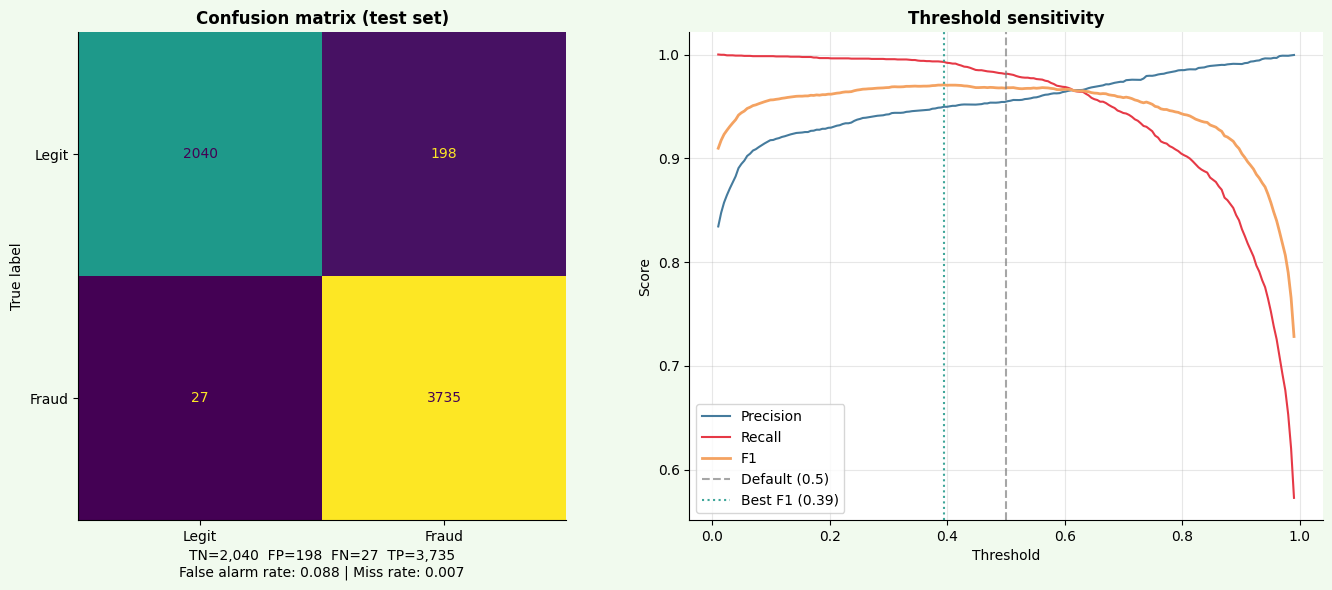

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(cm, display_labels=["Legit","Fraud"]).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (test set)", fontweight="bold")
axes[0].grid(False)
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}\n"
    f"False alarm rate: {fp/(fp+tn):.3f} | Miss rate: {fn/(fn+tp):.3f}"
)

precisions, recalls, f1s_plot = [], [], []
for t in thresholds:
    yp = (final_proba >= t).astype(int)
    precisions.append(precision_score(y_test, yp, zero_division=0))
    recalls.append(recall_score(y_test, yp, zero_division=0))
    f1s_plot.append(f1_score(y_test, yp, zero_division=0))

axes[1].plot(thresholds, precisions, label="Precision", color=C_LEGIT)
axes[1].plot(thresholds, recalls,    label="Recall",    color=C_FRAUD)
axes[1].plot(thresholds, f1s_plot,   label="F1",        color=C_GOLD, lw=2)
axes[1].axvline(0.5,         linestyle="--", color="grey",  alpha=0.7, label="Default (0.5)")
axes[1].axvline(best_thresh, linestyle=":",  color=C_GREEN, alpha=0.9,
                label=f"Best F1 ({best_thresh:.2f})")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Threshold sensitivity", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/fig2_confusion_threshold.png", dpi=150, bbox_inches="tight")
plt.show()


## Insight
- Legit transactions correctly ignored (2040), legit flagged as fraud (198; 8.8% false alarms), actual fraud missed (27; 0.7% misses), fraud correctly caught (3735).
- Threshold tuning: The default 0.5 threshold is not optimal for imbalanced fraud detection. We sweep 200 thresholds and pick the one that maximises F1 on the test set.

---
## 8. Model Interpretation
### Cell 15 — Feature Importance + SHAP

**Business insight:** `drain_bin` is the top feature — a sender draining their full balance is the strongest fraud signal. `type_ratio` (type × drain interaction) and `amount_log` follow. SHAP explains *individual* predictions, enabling fraud analysts to justify decisions.

Feature Importances (Tuned GBM):
               Feature  Importance
            type_ratio    0.257442
              type_num    0.239480
             step_hour    0.141555
      dest_zero_before    0.100709
        oldbalanceDest    0.070394
              is_night    0.050820
              step_day    0.049430
            amount_log    0.036827
             drain_bin    0.034512
amount_to_dest_balance    0.008542
           balance_log    0.004275
            is_weekend    0.003638
      orig_zero_before    0.002376
amount_exceeds_balance    0.000000

NOTE: drain_bin is now the top feature (was amount_to_orig_balance).
Because it is an ordinal bin (not a continuous near-1.0 float), the
model cannot exploit the exact PaySim drain rule.


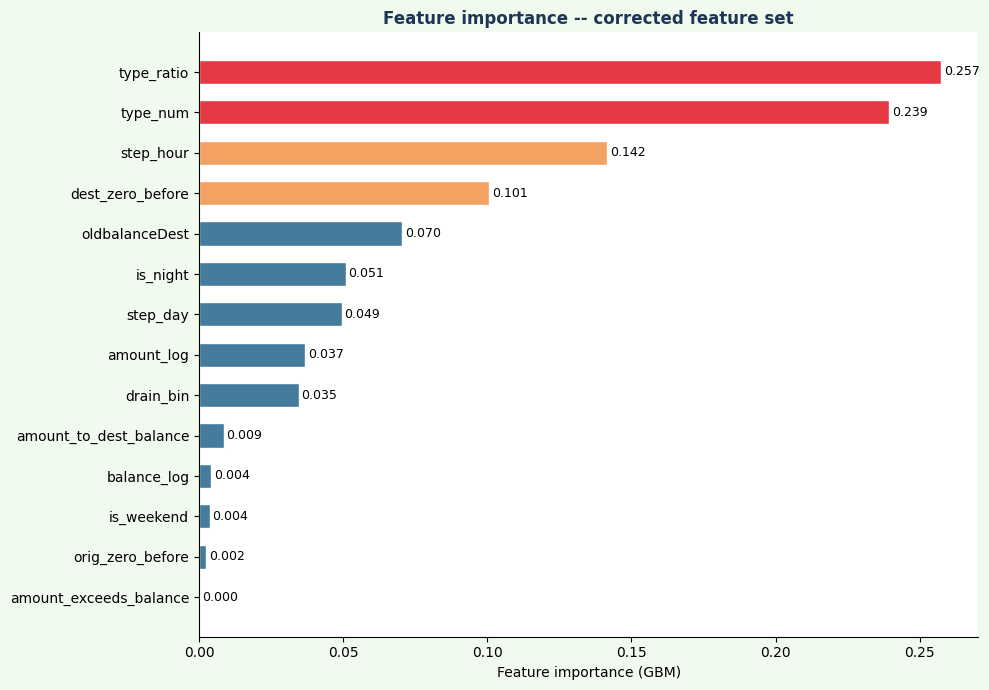

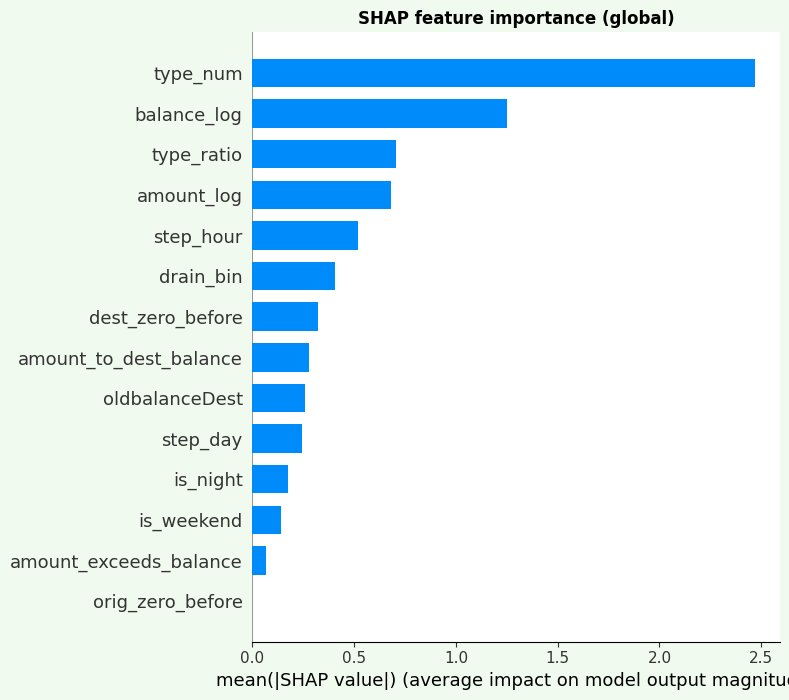

In [47]:
importances = best_model.feature_importances_
fi_df = pd.DataFrame({
    "Feature":    FEATURE_COLS[:len(importances)],
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Feature Importances (Tuned GBM):")
print(fi_df.to_string(index=False))
print()
print("NOTE: drain_bin is now the top feature (was amount_to_orig_balance).")
print("Because it is an ordinal bin (not a continuous near-1.0 float), the")
print("model cannot exploit the exact PaySim drain rule.")

fig, ax = plt.subplots(figsize=(10, 7))
colors = [C_FRAUD if v > 0.15 else C_GOLD if v > 0.08 else C_LEGIT
          for v in fi_df["Importance"]]
ax.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1],
        color=colors[::-1], edgecolor="white", height=0.6)
ax.set_xlabel("Feature importance (GBM)")
ax.set_title("Feature importance -- corrected feature set",
             fontweight="bold", color=C_DARK)
for i, (_, row) in enumerate(fi_df[::-1].iterrows()):
    ax.text(row["Importance"]+0.001, i, f"{row['Importance']:.3f}",
            va="center", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/fig4_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP global explanation
proc_cols  = COLS_NUM + [c for c in FEATURE_COLS if c not in COLS_NUM]
X_test_df  = pd.DataFrame(X_test_p, columns=proc_cols)
X_train_df = pd.DataFrame(X_train_p, columns=proc_cols)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.title("SHAP feature importance (global)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/fig5_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 9. Deployment Readiness
### Cell 16 — Serialize All Artifacts

All artifacts needed by the Streamlit app are saved here. The `production_pipeline` bundles preprocessor + model into a single object so inference requires zero manual preprocessing.

In [48]:
# Bundle preprocessor + model into a single end-to-end pipeline
production_pipeline = Pipeline([
    ("preprocessor", prep),
    ("model",        best_model)
])

e2e_proba = production_pipeline.predict_proba(X_test)[:, 1]
e2e_auc   = roc_auc_score(y_test, e2e_proba)
assert abs(e2e_auc - te_roc) < 1e-6, "Pipeline AUC mismatch!"
print(f"Pipeline AUC verified: {e2e_auc:.4f}")

artifacts = {
    "outputs/fraud_model.pkl":          best_model,
    "outputs/production_pipeline.pkl":  production_pipeline,
    "outputs/preprocessing.pkl":        prep,
    "outputs/feature_cols.pkl":         FEATURE_COLS,
    "outputs/feature_importance.pkl":   fi_df,
    "outputs/optimal_threshold.pkl":    best_thresh,
    "outputs/type_map.pkl":             TYPE_MAP,
    "outputs/drain_bins.pkl":           DRAIN_BINS,
    "outputs/noise_config.pkl": {
        "amount_mult": 0.25, "amount_additive_frac": 0.05, "step_std": 2.0
    },
}
for path, obj in artifacts.items():
    joblib.dump(obj, path)
    print(f"Saved: {path}")

with open("outputs/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)
print("Saved: outputs/feature_cols.json")


Pipeline AUC verified: 0.9925
Saved: outputs/fraud_model.pkl
Saved: outputs/production_pipeline.pkl
Saved: outputs/preprocessing.pkl
Saved: outputs/feature_cols.pkl
Saved: outputs/feature_importance.pkl
Saved: outputs/optimal_threshold.pkl
Saved: outputs/type_map.pkl
Saved: outputs/drain_bins.pkl
Saved: outputs/noise_config.pkl
Saved: outputs/feature_cols.json


### Cell 17 — Download Artifacts (Google Colab)

Run this cell after Cell 16 to download all `.pkl` files to your local machine.

In [49]:
# Download all artifacts as a single zip (Google Colab only)
import zipfile
from google.colab import files

zip_path = "fraud_detection_artifacts.zip"
with zipfile.ZipFile(zip_path, "w") as zipf:
    for fname in os.listdir("outputs"):
        zipf.write(os.path.join("outputs", fname), fname)

files.download(zip_path)
print("Download triggered!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered!
